# Exercise 01 : Line chart with styles




In [1]:
import pandas as pd
import sqlite3

data = sqlite3.connect('../data/checking-logs.sqlite')

df_views = pd.read_sql_query("SELECT datetime from pageviews WHERE uid LIKE 'user_%'", data)
df_commits = pd.read_sql_query("SELECT timestamp FROM checker WHERE uid LIKE 'user_%'", data)

data.close()

## Подготавливаем таблицу для графика




In [2]:
df_views['date'] = pd.to_datetime(df_views['datetime']).dt.date
df_grouped_views = df_views.groupby('date').size().reset_index(name='view')

df_commits['date'] = pd.to_datetime(df_commits['timestamp']).dt.date
df_grouped_commits = df_commits.groupby('date').size().reset_index(name='commit')

df_grouped = pd.merge(df_grouped_views, df_grouped_commits, on="date")
df_grouped

,date,view,commit
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


## Выводим график




<Axes: title={'center': 'Views and Commits per day'}, xlabel='date'>

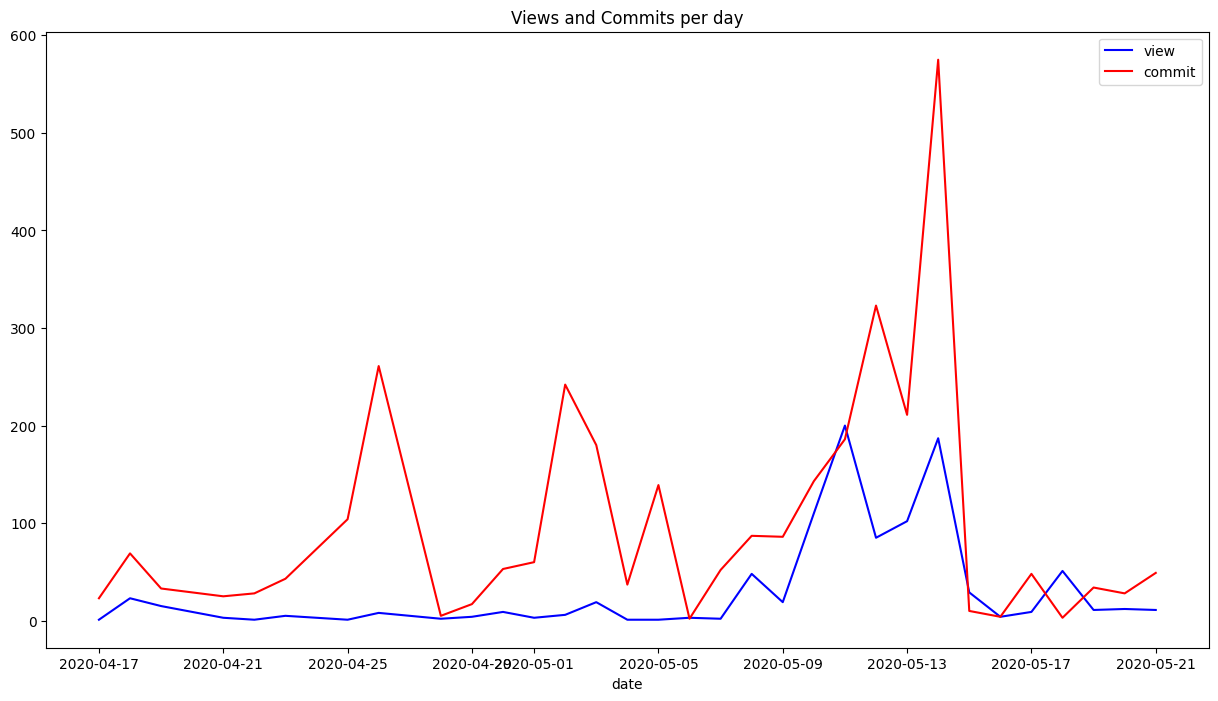

In [3]:
df_grouped.plot(
    x="date",
    y=["view", "commit"],
    kind="line",
    figsize=(15, 8),
    color=["blue", "red"],
    title="Views and Commits per day"
)

## How many times was the number of views larger than 150?
#### The answer is 2


